# Assignment 3 — From Raw Signals to a Lean Feature Set

**Course:** Feature Engineering & MLOps  
**Topic:** Time-based Features, Feature Creation + Filter / Wrapper / Embedded Selection

This notebook completes the assignment using the supplied `daily_batch_performance.csv`. The workflow follows Sections **4.1, 4.2, and 4.3** of the assignment brief.

## Setup and data loading

The assignment specifies 730 daily observations from 2024-01-01 to 2025-12-31. The code works both in the course repository (`data/raw/...`) and in the supplied-file environment.

In [1]:

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, LassoCV
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.feature_selection import RFE, mutual_info_regression
from sklearn.ensemble import RandomForestRegressor

candidate_paths = [
    Path("ASSIGNMENTS/data/daily_batch_performance.csv")
]
data_path = next((p for p in candidate_paths if p.exists()), None)
if data_path is None:
    raise FileNotFoundError("Could not find daily_batch_performance.csv")

df = pd.read_csv(data_path, parse_dates=["date"]).sort_values("date").reset_index(drop=True)
print(f"Loaded: {data_path}")
print(f"Shape: {df.shape}")
display(df.head())
display(df.dtypes.to_frame("dtype"))


Loaded: ASSIGNMENTS/data/daily_batch_performance.csv
Shape: (730, 10)


,date,marketing_spend,discount_pct,website_visits,website_visits_copy,competitor_promo_flag,is_holiday,random_noise_1,random_noise_2,new_enrollments
0,2024-01-01,9069.0,10,561.0,567.0,1,1,60.6,A,20
1,2024-01-02,6573.0,10,559.0,570.0,1,1,82.9,C,23
2,2024-01-03,14636.0,0,539.0,554.0,0,0,41.9,A,29
3,2024-01-04,3979.0,5,574.0,557.0,0,0,44.4,B,30
4,2024-01-05,9654.0,10,661.0,661.0,0,0,23.8,B,38


,dtype
date,datetime64[us]
marketing_spend,float64
discount_pct,int64
website_visits,float64
website_visits_copy,float64
competitor_promo_flag,int64
is_holiday,int64
random_noise_1,float64
random_noise_2,str
new_enrollments,int64


## 4.1 — Phase 3: Time-based Features & Feature Creation

### 1. Load, sort, and inspect `new_enrollments` over time

**Observation:** The series shows an overall upward trend with short-term/weekly fluctuations; weekend enrollments are also higher on average than weekdays.

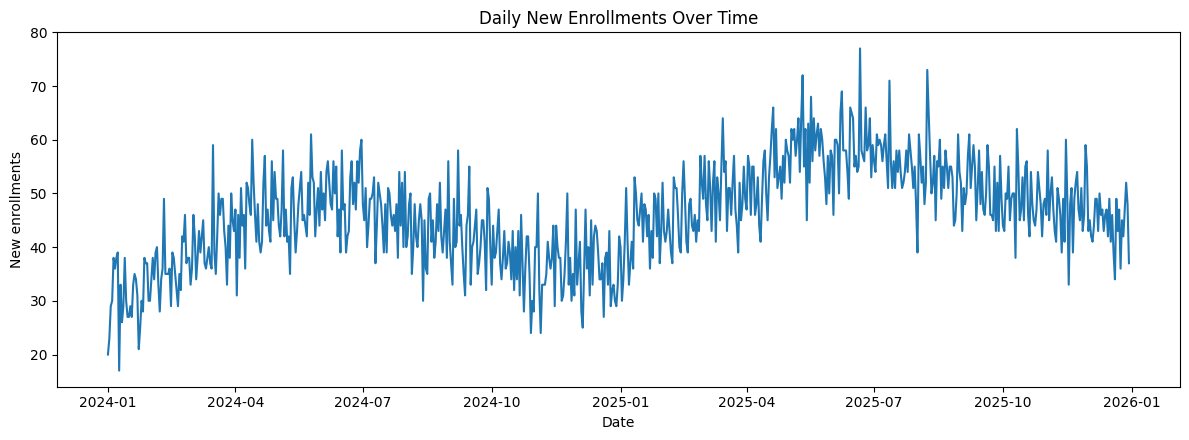

,day_name,dow,new_enrollments
1,Monday,0,44.733333
5,Tuesday,1,44.123810
6,Wednesday,2,44.846154
4,Thursday,3,44.298077
0,Friday,4,44.288462
2,Saturday,5,50.365385
3,Sunday,6,49.663462


In [2]:

plt.figure(figsize=(12, 4.5))
plt.plot(df["date"], df["new_enrollments"])
plt.title("Daily New Enrollments Over Time")
plt.xlabel("Date")
plt.ylabel("New enrollments")
plt.tight_layout()
plt.show()

weekday_summary = (
    df.assign(day_name=df["date"].dt.day_name(), dow=df["date"].dt.dayofweek)
      .groupby(["day_name", "dow"])["new_enrollments"].mean()
      .reset_index().sort_values("dow")
)
display(weekday_summary)


### 2. Lag features

Create `marketing_spend_lag1` and `marketing_spend_lag2`, then compare their correlations with same-day spend.

In [3]:

df["marketing_spend_lag1"] = df["marketing_spend"].shift(1)
df["marketing_spend_lag2"] = df["marketing_spend"].shift(2)
lag_corr = pd.Series({
    "marketing_spend (same day)": df["marketing_spend"].corr(df["new_enrollments"]),
    "marketing_spend_lag1": df["marketing_spend_lag1"].corr(df["new_enrollments"]),
    "marketing_spend_lag2": df["marketing_spend_lag2"].corr(df["new_enrollments"]),
}).sort_values(ascending=False)
display(lag_corr.to_frame("correlation_with_new_enrollments"))
print(f"Strongest correlation: {lag_corr.idxmax()} ({lag_corr.max():.4f}).")


,correlation_with_new_enrollments
marketing_spend_lag2,0.218377
marketing_spend (same day),0.118923
marketing_spend_lag1,-0.009213


Strongest correlation: marketing_spend_lag2 (0.2184).


**Interpretation:** `marketing_spend_lag2` is strongest, which matches the brief's real-world explanation that ad interest can take a couple of days to convert into a walk-in and enrollment.

### 3. Rolling features

Create a 7-day rolling mean and standard deviation of `new_enrollments`.

In [4]:

df["new_enrollments_roll7_mean"] = df["new_enrollments"].rolling(7).mean()
df["new_enrollments_roll7_std"] = df["new_enrollments"].rolling(7).std()
display(df[["date","new_enrollments","new_enrollments_roll7_mean","new_enrollments_roll7_std"]].head(10))


,date,new_enrollments,new_enrollments_roll7_mean,new_enrollments_roll7_std
0,2024-01-01,20,NaN,NaN
1,2024-01-02,23,NaN,NaN
2,2024-01-03,29,NaN,NaN
3,2024-01-04,30,NaN,NaN
4,2024-01-05,38,NaN,NaN
5,2024-01-06,36,NaN,NaN
6,2024-01-07,38,30.571429,7.207800
7,2024-01-08,39,33.285714,6.047432
8,2024-01-09,17,32.428571,7.892130
9,2024-01-10,33,33.000000,7.745967


**Leakage note:** The assignment explicitly asks for rolling features from `new_enrollments` itself, so the standard rolling window includes the current day. In a real forecasting setup, these target-derived features should be shifted to avoid leakage.

### 4. Cyclical day-of-week encoding

In [5]:

df["dow"] = df["date"].dt.dayofweek
df["dow_sin"] = np.sin(2*np.pi*df["dow"]/7)
df["dow_cos"] = np.cos(2*np.pi*df["dow"]/7)
display(df[["date","dow","dow_sin","dow_cos"]].head(10))


,date,dow,dow_sin,dow_cos
0,2024-01-01,0,0.000000,1.000000
1,2024-01-02,1,0.781831,0.623490
2,2024-01-03,2,0.974928,-0.222521
3,2024-01-04,3,0.433884,-0.900969
4,2024-01-05,4,-0.433884,-0.900969
5,2024-01-06,5,-0.974928,-0.222521
6,2024-01-07,6,-0.781831,0.623490
7,2024-01-08,0,0.000000,1.000000
8,2024-01-09,1,0.781831,0.623490
9,2024-01-10,2,0.974928,-0.222521


**Why not use plain 0–6?** Integer encoding wrongly makes Sunday (6) look far from Monday (0). Sine/cosine preserve the circular weekly relationship.

### 5. Trend feature

In [6]:

df["time_index"] = np.arange(len(df))
trend_model = LinearRegression().fit(df[["time_index"]], df["new_enrollments"])
daily_growth = float(trend_model.coef_[0])
print(f"Estimated daily growth: {daily_growth:.5f} enrollments/day")
print(f"Trend-only R²: {trend_model.score(df[['time_index']], df['new_enrollments']):.4f}")


Estimated daily growth: 0.02017 enrollments/day
Trend-only R²: 0.2158


**Result:** The estimated linear trend is approximately **0.0202 additional enrollments per day**.

### 6. Interaction feature

Create `spend_x_discount = marketing_spend_lag2 × discount_pct` and compare test R² with and without it. A chronological 80/20 split keeps the time ordering intact.

In [7]:

df["spend_x_discount"] = df["marketing_spend_lag2"] * df["discount_pct"]
model_df = df.dropna().copy()

base_features = [
    "marketing_spend","discount_pct","website_visits","website_visits_copy",
    "competitor_promo_flag","is_holiday","random_noise_1",
    "marketing_spend_lag1","marketing_spend_lag2",
    "new_enrollments_roll7_mean","new_enrollments_roll7_std",
    "dow_sin","dow_cos","time_index"
]
with_interaction = base_features + ["spend_x_discount"]

split_idx = int(len(model_df)*0.80)
train, test = model_df.iloc[:split_idx], model_df.iloc[split_idx:]
m_without = LinearRegression().fit(train[base_features], train["new_enrollments"])
m_with = LinearRegression().fit(train[with_interaction], train["new_enrollments"])
r2_without = r2_score(test["new_enrollments"], m_without.predict(test[base_features]))
r2_with = r2_score(test["new_enrollments"], m_with.predict(test[with_interaction]))

interaction_results = pd.DataFrame({
    "model":["Without interaction","With interaction"],
    "test_R2":[r2_without,r2_with],
})
interaction_results["change_vs_without"] = interaction_results["test_R2"] - r2_without
display(interaction_results)
print(f"Interaction ΔR² = {r2_with-r2_without:.6f}")


,model,test_R2,change_vs_without
0,Without interaction,0.626957,0.000000
1,With interaction,0.626823,-0.000134


Interaction ΔR² = -0.000134


**Conclusion:** The interaction slightly **reduces** test R² on this split (ΔR² ≈ **−0.00013**), so it does not provide a measurable performance gain here.

### 7. Drop leading NaN rows

In [8]:

before=len(df)
df_clean=df.dropna().copy()
print(f"Rows before drop: {before}")
print(f"Rows removed: {before-len(df_clean)}")
print(f"Rows remaining: {len(df_clean)}")


Rows before drop: 730
Rows removed: 6
Rows remaining: 724


**Why not mean/median impute?** These NaNs are structural: the earliest dates do not have enough prior history for the requested lag/full rolling window. Imputation would fabricate unavailable history.

## 4.2 — Phase 4: Feature Selection

`random_noise_2` is categorical, so it is ordinal-encoded **only for the numeric selection algorithms**. The numeric code does not imply an actual A < B < C relationship.

In [9]:

work=df_clean.copy()
noise_encoder=OrdinalEncoder()
work["random_noise_2_code"]=noise_encoder.fit_transform(work[["random_noise_2"]]).ravel()

candidate_features=[
    "marketing_spend","discount_pct","website_visits","website_visits_copy",
    "competitor_promo_flag","is_holiday","random_noise_1","random_noise_2_code",
    "marketing_spend_lag1","marketing_spend_lag2",
    "new_enrollments_roll7_mean","new_enrollments_roll7_std",
    "dow","dow_sin","dow_cos","time_index","spend_x_discount"
]
X=work[candidate_features]
y=work["new_enrollments"]
print(f"Candidate feature count: {len(candidate_features)}")


Candidate feature count: 17


### 1. Variance threshold

No feature is near-constant enough to justify removal. Binary features can have low variance while still carrying signal.

In [10]:

variance_table=X.var().sort_values().to_frame("variance")
display(variance_table)
near_constant=variance_table[variance_table["variance"]<=0.01]
print("No near-constant feature at threshold <= 0.01." if near_constant.empty else "Near-constant features found:")
if not near_constant.empty: display(near_constant)


,variance
is_holiday,3.338415e-02
competitor_promo_flag,1.241661e-01
dow_sin,5.003078e-01
dow_cos,5.010657e-01
random_noise_2_code,6.842175e-01
new_enrollments_roll7_std,2.203636e+00
dow,4.019356e+00
new_enrollments_roll7_mean,5.488377e+01
discount_pct,5.566795e+01
random_noise_1,1.506816e+02


No near-constant feature at threshold <= 0.01.


### 2. Correlation filtering

Use a 0.95 absolute-correlation flag for redundant predictors.

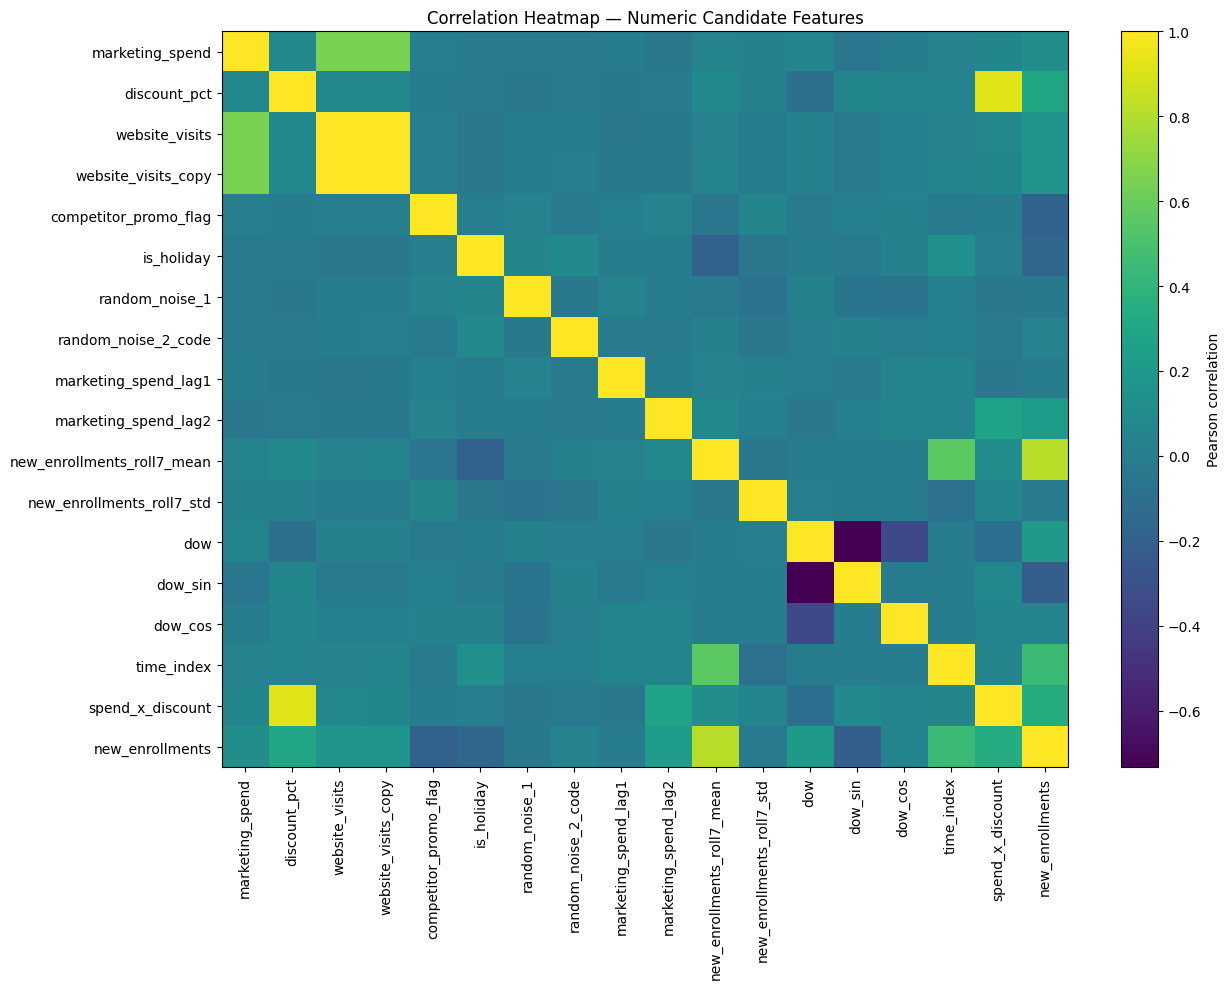

,feature_1,feature_2,correlation
0,website_visits,website_visits_copy,0.994657


In [11]:

corr_matrix=pd.concat([X,y.rename("new_enrollments")],axis=1).corr()
plt.figure(figsize=(13,10))
plt.imshow(corr_matrix,aspect="auto")
plt.colorbar(label="Pearson correlation")
plt.xticks(range(len(corr_matrix.columns)),corr_matrix.columns,rotation=90)
plt.yticks(range(len(corr_matrix.columns)),corr_matrix.columns)
plt.title("Correlation Heatmap — Numeric Candidate Features")
plt.tight_layout(); plt.show()

pairs=[]
cols=X.columns.tolist()
for i,a in enumerate(cols):
    for b in cols[i+1:]:
        v=corr_matrix.loc[a,b]
        if abs(v)>=0.95: pairs.append((a,b,v))
high_corr_df=pd.DataFrame(sorted(pairs,key=lambda t:-abs(t[2])),
                          columns=["feature_1","feature_2","correlation"])
display(high_corr_df)


**Decision:** `website_visits` and `website_visits_copy` are the clear near-duplicate pair (|r| ≈ **0.995**). Keep the original `website_visits`; drop the planted copy.

### 3. Mutual information

Compute `mutual_info_regression` for all numeric candidates. The categorical code is marked as discrete.

In [12]:

discrete_mask=np.zeros(len(candidate_features),dtype=bool)
discrete_mask[candidate_features.index("random_noise_2_code")]=True

mi_values=mutual_info_regression(
    X, y, discrete_features=discrete_mask, random_state=42
)
mi_table=pd.DataFrame({
    "feature":candidate_features,
    "mutual_information":mi_values
}).sort_values("mutual_information",ascending=False).reset_index(drop=True)
display(mi_table)

print("Noise feature positions:")
for f in ["random_noise_1","random_noise_2_code"]:
    row=mi_table.index[mi_table.feature==f][0]
    print(f"  {f}: rank {row+1}/{len(mi_table)}, MI={mi_table.loc[row,'mutual_information']:.6f}")


,feature,mutual_information
0,new_enrollments_roll7_mean,0.540418
1,time_index,0.490531
2,spend_x_discount,0.067279
3,competitor_promo_flag,0.044997
4,dow_sin,0.027473
5,discount_pct,0.026479
6,dow,0.024914
7,random_noise_2_code,0.007163
8,new_enrollments_roll7_std,0.005940
9,random_noise_1,0.003265


Noise feature positions:
  random_noise_1: rank 10/17, MI=0.003265
  random_noise_2_code: rank 8/17, MI=0.007163


**Interpretation:** Both noise features have very low MI scores. `random_noise_1` has MI ≈ **0.0033** and `random_noise_2` ≈ **0.0072**; neither is among the strong signals in the dataset.

### 4. Chi-square / ANOVA F-test trick question

Chi-square and the usual ANOVA F-test classification filter (`f_classif`) expect a **categorical/class target**. Here `new_enrollments` is a **continuous regression target**, so they are not the right target-filtering tools for this assignment; `mutual_info_regression` and regression-based wrappers/embedded methods fit the problem type.

### 5. Wrapper method — RFE

In [13]:

scaler_rfe=StandardScaler()
X_scaled=scaler_rfe.fit_transform(X)
rfe=RFE(LinearRegression(),n_features_to_select=6,step=1)
rfe.fit(X_scaled,y)

rfe_table=pd.DataFrame({
    "feature":candidate_features,
    "RFE_rank":rfe.ranking_,
    "RFE_selected":np.where(rfe.support_,"kept","dropped")
}).sort_values(["RFE_rank","feature"]).reset_index(drop=True)
display(rfe_table)
print("Top 6 selected by RFE:")
print(rfe_table.loc[rfe_table.RFE_rank==1,"feature"].tolist())


,feature,RFE_rank,RFE_selected
0,competitor_promo_flag,1,kept
1,discount_pct,1,kept
2,dow,1,kept
3,dow_cos,1,kept
4,marketing_spend_lag2,1,kept
5,new_enrollments_roll7_mean,1,kept
6,website_visits,2,dropped
7,dow_sin,3,dropped
8,website_visits_copy,4,dropped
9,marketing_spend_lag1,5,dropped


Top 6 selected by RFE:
['competitor_promo_flag', 'discount_pct', 'dow', 'dow_cos', 'marketing_spend_lag2', 'new_enrollments_roll7_mean']


### 6. Embedded method — LassoCV

In [14]:

scaler_lasso=StandardScaler()
X_scaled_lasso=scaler_lasso.fit_transform(X)
lasso=LassoCV(cv=5,random_state=42,max_iter=100000).fit(X_scaled_lasso,y)

lasso_table=pd.DataFrame({
    "feature":candidate_features,
    "coefficient":lasso.coef_,
    "abs_coefficient":np.abs(lasso.coef_)
}).sort_values("abs_coefficient",ascending=False).reset_index(drop=True)
display(lasso_table)
print(f"LassoCV alpha: {lasso.alpha_:.6f}")

exact_zero=lasso_table.loc[lasso_table.coefficient==0,"feature"].tolist()
near_zero=lasso_table.loc[
    (lasso_table.coefficient!=0)&(lasso_table.abs_coefficient<0.10),"feature"
].tolist()
print("Exactly zero:",exact_zero)
print("Near-zero (|coefficient| < 0.10):",near_zero)


,feature,coefficient,abs_coefficient
0,new_enrollments_roll7_mean,6.922875,6.922875
1,dow,1.892205,1.892205
2,discount_pct,1.791254,1.791254
3,marketing_spend_lag2,1.545964,1.545964
4,competitor_promo_flag,-1.442122,1.442122
5,website_visits,1.043711,1.043711
6,dow_cos,0.975562,0.975562
7,dow_sin,-0.626152,0.626152
8,spend_x_discount,0.266339,0.266339
9,marketing_spend_lag1,-0.168621,0.168621


LassoCV alpha: 0.042257
Exactly zero: ['random_noise_1', 'website_visits_copy', 'marketing_spend']
Near-zero (|coefficient| < 0.10): ['new_enrollments_roll7_std', 'is_holiday', 'time_index']


### 7. Compare filter / wrapper / embedded

For one reproducible **Filter** column, use the combined rules: variance > 0.01, not the correlation-flagged duplicate, and MI > 0.01. This threshold is an assignment reporting rule, not a universal constant.

In [15]:

mi_threshold=0.01
filter_kept=set()
for f in candidate_features:
    var_ok=X[f].var()>0.01
    corr_ok=f!="website_visits_copy"
    mi_score=float(mi_table.loc[mi_table.feature==f,"mutual_information"].iloc[0])
    if var_ok and corr_ok and mi_score>mi_threshold:
        filter_kept.add(f)

rfe_status=dict(zip(rfe_table.feature,rfe_table.RFE_selected))
lasso_abs=dict(zip(lasso_table.feature,lasso_table.abs_coefficient))
comparison=pd.DataFrame({
    "feature":candidate_features,
    "filter":["kept" if f in filter_kept else "dropped" for f in candidate_features],
    "wrapper_RFE":[rfe_status[f] for f in candidate_features],
    "embedded_Lasso":[("dropped" if lasso_abs[f]<0.10 else "kept") for f in candidate_features],
})
display(comparison)
print("Noise columns:")
display(comparison[comparison.feature.isin(["random_noise_1","random_noise_2_code"])])
print("Redundant column:")
display(comparison[comparison.feature=="website_visits_copy"])


,feature,filter,wrapper_RFE,embedded_Lasso
0,marketing_spend,dropped,dropped,dropped
1,discount_pct,kept,kept,kept
2,website_visits,dropped,dropped,kept
3,website_visits_copy,dropped,dropped,dropped
4,competitor_promo_flag,kept,kept,kept
5,is_holiday,dropped,dropped,dropped
6,random_noise_1,dropped,dropped,dropped
7,random_noise_2_code,dropped,dropped,kept
8,marketing_spend_lag1,dropped,dropped,kept
9,marketing_spend_lag2,dropped,kept,kept


Noise columns:


,feature,filter,wrapper_RFE,embedded_Lasso
6,random_noise_1,dropped,dropped,dropped
7,random_noise_2_code,dropped,dropped,kept


Redundant column:


,feature,filter,wrapper_RFE,embedded_Lasso
3,website_visits_copy,dropped,dropped,dropped


**Comparison takeaway:** The methods do not agree perfectly. `random_noise_1` is rejected strongly, while the encoded categorical noise column retains a small spurious linear coefficient, illustrating that stochastic sample associations can survive some methods. The planted `website_visits_copy` is caught by correlation filtering and Lasso, while RFE ranks it below the selected top six.

## 4.3 — Reflection Questions

### 1. Most useful engineered feature
The **7-day rolling mean of `new_enrollments`** is the strongest engineered feature in this run: it has the highest mutual information, is selected by RFE, and receives the largest Lasso coefficient. That matches the intuition that recent enrollment history is strongly informative about current enrollments.

### 2. RFE vs Lasso disagreement
For this dataset, I would trust **Lasso slightly more as the final lean-model choice** because it evaluates all predictors jointly and explicitly penalizes redundant/noisy coefficients. RFE is still useful as a cross-check, but correlated predictors can compete during recursive elimination.

### 3. New competitor-promotion column
The analysis would need to be **redone**. The new feature was not present when the current filter, RFE, and Lasso results were computed, so the old rankings cannot automatically classify it. Feature selection depends on the available candidate set and data.

## Bonus — Random Forest embedded importance (+10%)

In [16]:

rf=RandomForestRegressor(n_estimators=500,random_state=42,n_jobs=-1)
rf.fit(X,y)
rf_table=pd.DataFrame({
    "feature":candidate_features,
    "RF_importance":rf.feature_importances_
}).sort_values("RF_importance",ascending=False).reset_index(drop=True)
display(rf_table.head(10))
display(rf_table[rf_table.feature.isin(["website_visits","website_visits_copy"])])
print("Tree-based importance can split across correlated predictors because either duplicate can substitute for the other across different trees/splits.")


,feature,RF_importance
0,new_enrollments_roll7_mean,0.688105
1,spend_x_discount,0.075448
2,dow_sin,0.039736
3,dow,0.032211
4,new_enrollments_roll7_std,0.028433
5,marketing_spend_lag2,0.026721
6,marketing_spend_lag1,0.015852
7,time_index,0.015653
8,random_noise_1,0.014944
9,website_visits_copy,0.014164


,feature,RF_importance
9,website_visits_copy,0.014164
11,website_visits,0.013365


Tree-based importance can split across correlated predictors because either duplicate can substitute for the other across different trees/splits.


## Final results summary

* **Strongest marketing timing signal:** `marketing_spend_lag2`, correlation ≈ **0.2184** vs same-day ≈ **0.1189**.
* **Trend:** about **0.0202 enrollments/day**.
* **Interaction:** no gain on the chronological 80/20 test split; ΔR² ≈ **−0.00013**.
* **Variance:** no near-constant feature at the chosen check threshold.
* **Correlation:** `website_visits_copy` is the planted near-duplicate (|r| ≈ **0.995**).
* **MI:** the 7-day rolling mean and `time_index` are strongest; the noise columns are near the bottom.
* **RFE top 6:** `discount_pct`, `competitor_promo_flag`, `new_enrollments_roll7_mean`, `marketing_spend_lag2`, `dow_cos`, `dow`.
* **Lasso:** `marketing_spend`, `random_noise_1`, and `website_visits_copy` shrink to exactly zero.

Save as `Assignments/Assignment3_TimeFeatures_Selection.ipynb` and run all cells top-to-bottom before committing.